# Análise Exploratória de Dados (EDA)

## IBM HR Analytics Employee Attrition Dataset

Este notebook apresenta a análise exploratória dos dados utilizados no projeto de People Analytics.

**Variável alvo**: `Attrition` (Yes/No) — indica se o colaborador deixou a empresa.

In [88]:
import re
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Carregar dados
df = pd.read_csv('../data/raw/WA_Fn-UseC_-HR-Employee-Attrition.csv')
print(f'Shape: {df.shape}')
print(f'Colunas: {df.columns.tolist()}')

Shape: (1470, 35)
Colunas: ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


## 1. Visão Geral dos Dados

In [89]:
# Informações gerais
print('=== Info ===')
print(f'Linhas: {len(df)}')
print(f'Colunas: {len(df.columns)}')
print(f'\nValores nulos: {df.isnull().sum().sum()}')
print(f'\nTipos de dados:')
print(df.dtypes.value_counts())

# Colunas constantes (remover)
for col in ['EmployeeCount', 'Over18', 'StandardHours']:
    if col in df.columns:
        print(f'\n{col}: {df[col].unique()} (constante — será removida)')

=== Info ===
Linhas: 1470
Colunas: 35

Valores nulos: 0

Tipos de dados:
int64     26
object     9
Name: count, dtype: int64

EmployeeCount: [1] (constante — será removida)

Over18: ['Y'] (constante — será removida)

StandardHours: [80] (constante — será removida)


## 2. Distribuição da Variável Alvo

In [90]:
# Distribuição de Attrition
attrition_counts = df['Attrition'].value_counts()
print(f'Attrition:\n{attrition_counts}')
print(f'\nTaxa de attrition: {attrition_counts["Yes"] / len(df):.1%}')

fig = px.pie(values=attrition_counts.values, names=attrition_counts.index,
             title='Distribuição de Attrition', color_discrete_sequence=['#2ecc71', '#e74c3c'])
fig.show()

Attrition:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Taxa de attrition: 16.1%


## 3. Análise de Features Numéricas

In [91]:
# Distribuição das principais features numéricas por Attrition
numeric_features = ['Age', 'MonthlyIncome', 'YearsAtCompany', 'DistanceFromHome',
                     'TotalWorkingYears', 'YearsSinceLastPromotion']

fig = make_subplots(rows=2, cols=3, subplot_titles=numeric_features)

for i, feat in enumerate(numeric_features):
    row, col = i // 3 + 1, i % 3 + 1
    for attrition, color in [('No', '#2ecc71'), ('Yes', '#e74c3c')]:
        data = df[df['Attrition'] == attrition][feat]
        fig.add_trace(
            go.Histogram(x=data, name=attrition, marker_color=color, opacity=0.7),
            row=row, col=col
        )

fig.update_layout(height=600, title_text='Distribuição por Attrition', showlegend=False)
fig.show()

## 4. Análise de Features Categóricas

In [92]:
# Taxa de attrition por departamento
dept_attrition = df.groupby('Department')['Attrition'].apply(
    lambda x: (x == 'Yes').mean()
).reset_index()
dept_attrition.columns = ['Departamento', 'Taxa de Attrition']

fig = px.bar(dept_attrition.sort_values('Taxa de Attrition', ascending=False),
             x='Departamento', y='Taxa de Attrition',
             title='Taxa de Attrition por Departamento',
             color='Taxa de Attrition', color_continuous_scale=['green', 'red'])
fig.update_layout(yaxis_tickformat='.0%')
fig.show()

In [93]:
# Taxa de attrition por OverTime
ot_attrition = df.groupby('OverTime')['Attrition'].apply(
    lambda x: (x == 'Yes').mean()
).reset_index()
ot_attrition.columns = ['Hora Extra', 'Taxa de Attrition']

fig = px.bar(ot_attrition, x='Hora Extra', y='Taxa de Attrition',
             title='Taxa de Attrition por Hora Extra',
             color='Taxa de Attrition', color_continuous_scale=['green', 'red'])
fig.update_layout(yaxis_tickformat='.0%')
fig.show()

## 5. Correlações

In [94]:
# Correlação das features numéricas com Attrition
df_encoded = df.copy()
df_encoded['Attrition_binary'] = (df_encoded['Attrition'] == 'Yes').astype(int)

numeric_cols = df_encoded.select_dtypes(include=[np.number]).columns
correlations = df_encoded[numeric_cols].corr()['Attrition_binary'].drop('Attrition_binary')
correlations = correlations.abs().sort_values(ascending=False).head(15)

fig = px.bar(x=correlations.values, y=correlations.index, orientation='h',
             title='Top 15 — Correlação com Attrition (valor absoluto)',
             labels={'x': 'Correlação', 'y': 'Feature'})
fig.update_layout(height=500, yaxis=dict(autorange='reversed'))
fig.show()

## Estatísticas Descritivas

Visão resumida de todas as variáveis numéricas — média, desvio, quartis — pra entender escala e dispersão antes de qualquer modelagem.

In [95]:
# Estatísticas das features numéricas (exceto IDs e constantes)
cols_desc = ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction',
             'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate',
             'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating',
             'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears',
             'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany',
             'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
df[cols_desc].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.92,9.14,18.0,30.0,36.0,43.0,60.0
DailyRate,1470.0,802.49,403.51,102.0,465.0,802.0,1157.0,1499.0
DistanceFromHome,1470.0,9.19,8.11,1.0,2.0,7.0,14.0,29.0
Education,1470.0,2.91,1.02,1.0,2.0,3.0,4.0,5.0
EnvironmentSatisfaction,1470.0,2.72,1.09,1.0,2.0,3.0,4.0,4.0
JobInvolvement,1470.0,2.73,0.71,1.0,2.0,3.0,3.0,4.0
JobLevel,1470.0,2.06,1.11,1.0,1.0,2.0,3.0,5.0
JobSatisfaction,1470.0,2.73,1.10,1.0,2.0,3.0,4.0,4.0
MonthlyIncome,1470.0,6502.93,4707.96,1009.0,2911.0,4919.0,8379.0,19999.0
MonthlyRate,1470.0,14313.10,7117.79,2094.0,8047.0,14235.5,20461.5,26999.0


### Unicidade e nulos

Cardinalidade das categóricas + ausência total de nulos no dataset IBM.

In [96]:
info = pd.DataFrame({
    'dtype': df.dtypes,
    'nulos': df.isnull().sum(),
    'uniques': df.nunique(),
}).sort_values('uniques')
info

,dtype,nulos,uniques
Over18,object,0,1
StandardHours,int64,0,1
EmployeeCount,int64,0,1
Gender,object,0,2
Attrition,object,0,2
PerformanceRating,int64,0,2
OverTime,object,0,2
MaritalStatus,object,0,3
Department,object,0,3
BusinessTravel,object,0,3


## Outliers nas features numéricas principais

Boxplots por Attrition revelam se existem pontos extremos que merecem atenção (clipping, winsorization) antes do treino.

In [97]:
outlier_features = ['MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany', 'NumCompaniesWorked']
fig = make_subplots(rows=2, cols=2, subplot_titles=outlier_features)
for i, feat in enumerate(outlier_features):
    row, col = i // 2 + 1, i % 2 + 1
    for attr, color in [('No', '#10B981'), ('Yes', '#EF4444')]:
        fig.add_trace(
            go.Box(y=df[df['Attrition'] == attr][feat], name=attr, marker_color=color,
                   showlegend=(i == 0)),
            row=row, col=col,
        )
fig.update_layout(height=600, title_text='Outliers por Attrition')
fig.show()

## Análise Categórica Completa

Taxa de attrition pra todas as variáveis categóricas do dataset.

In [98]:
cat_features = ['Department', 'JobRole', 'MaritalStatus', 'BusinessTravel',
                'EducationField', 'Gender', 'OverTime']
fig = make_subplots(rows=3, cols=3, subplot_titles=cat_features,
                    specs=[[{}, {}, {}], [{}, {}, {}], [{}, None, None]],
                    vertical_spacing=0.15)
positions = [(1,1), (1,2), (1,3), (2,1), (2,2), (2,3), (3,1)]
for (feat, pos) in zip(cat_features, positions):
    rate = df.groupby(feat)['Attrition'].apply(lambda x: (x == 'Yes').mean()).sort_values(ascending=False)
    fig.add_trace(
        go.Bar(x=rate.index.astype(str), y=rate.values * 100,
               marker_color='#EF4444', showlegend=False,
               text=[f'{v*100:.1f}%' for v in rate.values], textposition='outside',
               cliponaxis=False),
        row=pos[0], col=pos[1],
    )
    # Aumenta range do Y pra dar espaço aos labels
    max_val = rate.max() * 100
    fig.update_yaxes(range=[0, max_val * 1.25], row=pos[0], col=pos[1])
fig.update_layout(height=900, title_text='Taxa de Attrition (%) por Variável Categórica',
                  margin=dict(t=80, b=40))
fig.update_yaxes(title_text='% Attrition')
fig.show()

## Features de Satisfação e Engajamento (escala 1-4)

O dataset tem 5 escalas ordinais de satisfação. Cada uma traz um ângulo diferente sobre o relacionamento do colaborador com a empresa.

In [99]:
sat_features = ['JobSatisfaction', 'EnvironmentSatisfaction', 'WorkLifeBalance',
                'JobInvolvement', 'RelationshipSatisfaction']
fig = make_subplots(rows=2, cols=3, subplot_titles=sat_features,
                    specs=[[{}, {}, {}], [{}, {}, None]],
                    vertical_spacing=0.18)
positions = [(1,1), (1,2), (1,3), (2,1), (2,2)]
for (feat, pos) in zip(sat_features, positions):
    rate = df.groupby(feat)['Attrition'].apply(lambda x: (x == 'Yes').mean())
    fig.add_trace(
        go.Bar(x=rate.index, y=rate.values * 100,
               marker_color=['#DC2626','#F59E0B','#3B82F6','#10B981'],
               showlegend=False,
               text=[f'{v*100:.1f}%' for v in rate.values], textposition='outside',
               cliponaxis=False),
        row=pos[0], col=pos[1],
    )
    max_val = rate.max() * 100
    fig.update_yaxes(range=[0, max_val * 1.25], row=pos[0], col=pos[1])
fig.update_layout(height=650, title_text='Taxa de Attrition (%) por Nível (1=baixo, 4=alto)',
                  margin=dict(t=80, b=40))
fig.show()

## Experiência e Tempo na Empresa

Todas as features relacionadas a tempo — de carreira, empresa, cargo, gestor. São altamente correlacionadas entre si (multicolinearidade), mas trazem ângulos diferentes sobre estabilidade.

In [100]:
tenure_features = ['TotalWorkingYears', 'YearsAtCompany', 'YearsInCurrentRole',
                   'YearsWithCurrManager', 'YearsSinceLastPromotion']
fig = make_subplots(rows=2, cols=3, subplot_titles=tenure_features,
                    specs=[[{}, {}, {}], [{}, {}, None]])
positions = [(1,1), (1,2), (1,3), (2,1), (2,2)]
for (feat, pos) in zip(tenure_features, positions):
    for attr, color in [('No', '#10B981'), ('Yes', '#EF4444')]:
        fig.add_trace(
            go.Histogram(x=df[df['Attrition'] == attr][feat], name=attr,
                         marker_color=color, opacity=0.65, showlegend=(pos == (1,1))),
            row=pos[0], col=pos[1],
        )
fig.update_layout(height=650, barmode='overlay',
                  title_text='Distribuição de Features Temporais por Attrition')
fig.show()

## Heatmap de Correlação Completo

Matriz de correlação entre todas as features numéricas. Ajuda a identificar:
- **Multicolinearidades** (correlações > 0.7 entre features)
- **Clusters** de variáveis relacionadas
- **Candidatas a drop** ou a combinação em uma feature composta

In [101]:
import plotly.figure_factory as ff
df_num = df_encoded[numeric_cols].drop(columns=['EmployeeCount', 'StandardHours', 'EmployeeNumber'], errors='ignore')
corr_matrix = df_num.corr().round(2)
fig = px.imshow(corr_matrix, text_auto=True, aspect='auto',
                color_continuous_scale='RdBu_r', zmin=-1, zmax=1,
                title='Matriz de Correlação — Features Numéricas')
fig.update_layout(height=800, width=900)
fig.show()

## Cruzamento Bidimensional — Department × JobRole

Heatmap de taxa de attrition por combinação de departamento e cargo. Revela grupos de risco específicos (ex: 'Sales Representative' no Sales pode ter taxa muito maior que 'Manager' no mesmo departamento).

In [102]:
pivot = df.pivot_table(index='JobRole', columns='Department',
                       values='Attrition', aggfunc=lambda x: (x == 'Yes').mean() * 100)
pivot = pivot.round(1)
fig = px.imshow(pivot, text_auto=True, aspect='auto',
                color_continuous_scale=['#10B981', '#FBBF24', '#DC2626'],
                labels=dict(color='% Attrition'),
                title='Taxa de Attrition (%) — JobRole × Department')
fig.update_layout(height=500)
fig.show()

## Efeito Combinado — OverTime × Satisfação

OverTime é o driver mais forte (já quantificado). Mas o efeito se amplifica quando combinado com baixa satisfação — mostrando que ações de retenção devem priorizar quem faz hora extra **e** tem baixa satisfação no trabalho.

In [103]:
combo = df.groupby(['OverTime', 'JobSatisfaction'])['Attrition'].apply(
    lambda x: (x == 'Yes').mean() * 100
).round(1).reset_index()
combo.columns = ['OverTime', 'JobSatisfaction', 'AttritionPct']
fig = px.bar(combo, x='JobSatisfaction', y='AttritionPct', color='OverTime',
             barmode='group', text='AttritionPct',
             color_discrete_map={'Yes': '#DC2626', 'No': '#10B981'},
             title='Attrition % — Hora Extra × Satisfação no Trabalho',
             labels={'JobSatisfaction': 'Satisfação (1=baixo, 4=alto)',
                     'AttritionPct': '% Attrition'})
fig.update_traces(texttemplate='%{text}%', textposition='outside')
fig.update_layout(height=450)
fig.show()

## 6. Quantificação das Observações

Antes de listar os insights, calculamos explicitamente as taxas de attrition por cada variável mencionada — pra que cada conclusão tenha base numérica.

In [104]:
# Hora extra — quantos vezes maior é a taxa de saída?
overtime_rate = df.groupby('OverTime')['Attrition'].apply(lambda x: (x == 'Yes').mean())
multiplier = overtime_rate['Yes'] / overtime_rate['No']
print('Taxa de attrition por OverTime:')
for ot, rate in overtime_rate.items():
    print(f'  OverTime={ot}: {rate:.1%}')
print(f'\nQuem faz hora extra tem {multiplier:.1f}x mais chance de sair.')

Taxa de attrition por OverTime:
  OverTime=No: 10.4%
  OverTime=Yes: 30.5%

Quem faz hora extra tem 2.9x mais chance de sair.


In [105]:
# Salário — attrition por faixa salarial
df_temp = df.copy()
df_temp['salary_band'] = pd.cut(
    df_temp['MonthlyIncome'],
    bins=[0, 2500, 5000, 7500, 10000, 20000],
    labels=['até 2.5k', '2.5k-5k', '5k-7.5k', '7.5k-10k', '10k+'],
)
salary_rate = df_temp.groupby('salary_band', observed=True)['Attrition'].apply(
    lambda x: (x == 'Yes').mean()
)
print('Taxa de attrition por faixa salarial (MonthlyIncome):')
for band, rate in salary_rate.items():
    print(f'  {band}: {rate:.1%}')
print(f'\nFaixa mais baixa tem {salary_rate.iloc[0] / salary_rate.iloc[-1]:.1f}x mais attrition que a mais alta.')

Taxa de attrition por faixa salarial (MonthlyIncome):
  até 2.5k: 34.1%
  2.5k-5k: 16.4%
  5k-7.5k: 9.7%
  7.5k-10k: 14.6%
  10k+: 8.9%

Faixa mais baixa tem 3.8x mais attrition que a mais alta.


In [106]:
# Distância de casa — attrition por faixa
df_temp = df.copy()
df_temp['dist_band'] = pd.cut(
    df_temp['DistanceFromHome'],
    bins=[0, 5, 10, 20, 30],
    labels=['0-5 km', '5-10 km', '10-20 km', '20-30 km'],
)
dist_rate = df_temp.groupby('dist_band', observed=True)['Attrition'].apply(
    lambda x: (x == 'Yes').mean()
)
print('Taxa de attrition por distância de casa:')
for band, rate in dist_rate.items():
    print(f'  {band}: {rate:.1%}')

Taxa de attrition por distância de casa:
  0-5 km: 13.8%
  5-10 km: 14.5%
  10-20 km: 20.0%
  20-30 km: 22.1%


In [107]:
# Tempo sem promoção
df_temp = df.copy()
df_temp['promo_band'] = pd.cut(
    df_temp['YearsSinceLastPromotion'],
    bins=[-0.1, 1, 3, 7, 15],
    labels=['0-1 ano', '2-3 anos', '4-7 anos', '8+ anos'],
)
promo_rate = df_temp.groupby('promo_band', observed=True)['Attrition'].apply(
    lambda x: (x == 'Yes').mean()
)
print('Taxa de attrition por tempo sem promoção:')
for band, rate in promo_rate.items():
    print(f'  {band}: {rate:.1%}')

Taxa de attrition por tempo sem promoção:
  0-1 ano: 17.0%
  2-3 anos: 17.1%
  4-7 anos: 13.6%
  8+ anos: 12.1%


In [108]:
# Idade — jovens vs não-jovens
df_temp = df.copy()
df_temp['age_band'] = pd.cut(
    df_temp['Age'],
    bins=[17, 25, 35, 45, 65],
    labels=['18-25', '26-35', '36-45', '46+'],
)
age_rate = df_temp.groupby('age_band', observed=True)['Attrition'].apply(
    lambda x: (x == 'Yes').mean()
)
print('Taxa de attrition por faixa etária:')
for band, rate in age_rate.items():
    print(f'  {band}: {rate:.1%}')

# Comparação direta: < 35 vs >= 35
jovens = df[df['Age'] < 35]
mais_velhos = df[df['Age'] >= 35]
rate_jovens = (jovens['Attrition'] == 'Yes').mean()
rate_velhos = (mais_velhos['Attrition'] == 'Yes').mean()
print(f'\n< 35 anos: {rate_jovens:.1%} attrition')
print(f'>= 35 anos: {rate_velhos:.1%} attrition')
print(f'Jovens têm {rate_jovens / rate_velhos:.1f}x mais attrition.')

Taxa de attrition por faixa etária:
  18-25: 35.8%
  26-35: 19.1%
  36-45: 9.2%
  46+: 12.5%

< 35 anos: 23.0% attrition
>= 35 anos: 10.6% attrition
Jovens têm 2.2x mais attrition.


In [109]:
# Departamento — qual tem a maior taxa
dept_rate = df.groupby('Department')['Attrition'].apply(lambda x: (x == 'Yes').mean()).sort_values(ascending=False)
print('Taxa de attrition por departamento:')
for dept, rate in dept_rate.items():
    print(f'  {dept}: {rate:.1%}')
print(f'\n{dept_rate.index[0]} lidera com {dept_rate.iloc[0]:.1%}.')

Taxa de attrition por departamento:
  Sales: 20.6%
  Human Resources: 19.0%
  Research & Development: 13.8%

Sales lidera com 20.6%.


## 7. Insights Principais

Cada claim abaixo é **suportado numericamente** pelas células anteriores (§6).

1. **Dataset desbalanceado** — 16.1% de attrition. Justifica SMOTE por fold e threshold otimizado por Youden's J em vez do 0.5 padrão.
2. **Hora extra é o driver mais forte** — quem faz hora extra tem **2.9x mais chance** de sair (30.5% vs 10.4%).
3. **Salário baixo pesa muito na faixa inicial** — até R$ 2.5k tem **34.1% de attrition**, contra 8.9% na faixa 10k+ (3.8x). A relação não é perfeitamente monotônica: 5-7.5k (9.7%) fica abaixo de 7.5-10k (14.6%), sugerindo que o efeito do salário é mais forte nos extremos.
4. **Distância de casa tem relação quase linear** — 13.8% nos 0-5km vs 22.1% nos 20-30km. Fator relevante mas de menor magnitude que hora extra.
5. **Jovens saem muito mais** — 18-25 anos = 35.8%, 26-35 = 19.1%, 36+ = ~10%. Quem tem **< 35 anos tem 2.2x mais attrition** do que quem tem 35+.
6. **Departamento**: Sales lidera com 20.6%, seguido de HR (19.0%), e R&D com 13.8%.
7. **Tempo sem promoção surpreende** — a relação é **inversa** ao esperado: 0-1 ano = 17%, 8+ anos = 12.1%. Interpretação: quem ainda não foi promovido e está na empresa há muitos anos tende a ser perfil acomodado (baixa saída), enquanto quem está em janela curta sem promoção pode estar no auge da insatisfação. **Insight contraintuitivo que vale levar pro modelo**.

### Implicações para modelagem

- **Features mais preditivas esperadas**: OverTime, Age, MonthlyIncome, DistanceFromHome, Department, JobRole
- **Feature engineering útil**: `tenure_ratio`, `satisfaction_index`, `career_stagnation`, `salary_vs_level` (detecta pessoas sub-valorizadas)
- **Drop**: EmployeeCount, Over18, StandardHours (constantes); EmployeeNumber (só ID)
- **Estratégia**: SMOTE por fold + threshold otimizado + comparação de 4 modelos (LogReg, RF, XGBoost, LightGBM) com Optuna

## 8. Treino do Modelo — pipeline completo inline

O objetivo desta seção é **mostrar o código real** de treino.
Reproduzimos a mesma lógica que o `make train` executa em produção, usando a mesma seed.

**Etapas**:
1. Feature engineering de domínio
2. Preprocessamento (StandardScaler + OneHot + OrdinalEncoder via `ColumnTransformer`)
3. Stratified K-Fold com SMOTE por fold (evita data leakage)
4. Optuna para 4 modelos — LogReg, RandomForest, XGBoost, LightGBM
5. Calibração via Platt Scaling
6. Escolha do melhor modelo individual + Threshold via Youden's J
7. Explicabilidade com SHAP

### 8.1. Feature Engineering de Domínio

Criamos features derivadas que capturam padrões específicos de People Analytics — cada uma
responde a uma hipótese de negócio sobre o que leva um colaborador a sair.

In [110]:
# Renomeia CamelCase → snake_case (o pipeline real faz isso no loader)
COLUMN_MAP = {
    'Age': 'age', 'Attrition': 'attrition', 'BusinessTravel': 'business_travel',
    'DailyRate': 'daily_rate', 'Department': 'department',
    'DistanceFromHome': 'distance_from_home', 'Education': 'education',
    'EducationField': 'education_field', 'EmployeeNumber': 'employee_number',
    'EnvironmentSatisfaction': 'environment_satisfaction', 'Gender': 'gender',
    'HourlyRate': 'hourly_rate', 'JobInvolvement': 'job_involvement',
    'JobLevel': 'job_level', 'JobRole': 'job_role',
    'JobSatisfaction': 'job_satisfaction', 'MaritalStatus': 'marital_status',
    'MonthlyIncome': 'monthly_income', 'MonthlyRate': 'monthly_rate',
    'NumCompaniesWorked': 'num_companies_worked', 'OverTime': 'over_time',
    'PercentSalaryHike': 'percent_salary_hike', 'PerformanceRating': 'performance_rating',
    'RelationshipSatisfaction': 'relationship_satisfaction',
    'StockOptionLevel': 'stock_option_level', 'TotalWorkingYears': 'total_working_years',
    'TrainingTimesLastYear': 'training_times_last_year',
    'WorkLifeBalance': 'work_life_balance', 'YearsAtCompany': 'years_at_company',
    'YearsInCurrentRole': 'years_in_current_role',
    'YearsSinceLastPromotion': 'years_since_last_promotion',
    'YearsWithCurrManager': 'years_with_curr_manager',
}
DROP_CONSTANTS = ['EmployeeCount', 'Over18', 'StandardHours']
df_snake = df.drop(columns=[c for c in DROP_CONSTANTS if c in df.columns]).rename(columns=COLUMN_MAP)

# Feature engineering — 5 features de domínio
def add_domain_features(d):
    d = d.copy()
    # tenure_ratio: quanto da carreira foi nessa empresa
    d['tenure_ratio'] = np.where(d['total_working_years'] > 0,
                                  d['years_at_company'] / d['total_working_years'], 0.0)
    # satisfaction_index: média das 4 dimensões de satisfação (escala 1-4)
    sat_cols = ['environment_satisfaction', 'job_satisfaction',
                'relationship_satisfaction', 'work_life_balance']
    d['satisfaction_index'] = d[sat_cols].mean(axis=1)
    # career_stagnation: anos sem promoção / anos na empresa
    d['career_stagnation'] = np.where(d['years_at_company'] > 0,
                                       d['years_since_last_promotion'] / d['years_at_company'], 0.0)
    # salary_vs_level: quanto ganha relativo ao nível do cargo (detecta sub-valorização)
    d['salary_vs_level'] = d['monthly_income'] / d['job_level']
    # years_per_company: média de anos por empresa (baixo = job-hopping)
    d['years_per_company'] = np.where(d['num_companies_worked'] > 0,
                                       d['total_working_years'] / d['num_companies_worked'],
                                       d['total_working_years'])
    return d

df_feat = add_domain_features(df_snake)
new_feats = ['tenure_ratio', 'satisfaction_index', 'career_stagnation',
             'salary_vs_level', 'years_per_company']
df_feat[new_feats].describe().round(3)

,tenure_ratio,satisfaction_index,career_stagnation,salary_vs_level,years_per_company
count,1470.000,1470.000,1470.000,1470.000,1470.000
mean,0.678,2.731,0.290,2973.801,6.132
std,0.328,0.506,0.341,770.641,5.646
min,0.000,1.000,0.000,1009.000,0.000
25%,0.412,2.500,0.000,2394.125,2.036
50%,0.800,2.750,0.167,2856.500,4.633
75%,1.000,3.000,0.500,3478.833,9.000
max,1.000,4.000,1.000,4999.000,40.000


### 8.2. Preprocessamento — ColumnTransformer

Três tipos de tratamento conforme a natureza da variável:
- **Numéricas contínuas** → `StandardScaler` (média 0, desvio 1)
- **Ordinais** (escalas 1-4, níveis 1-5) → `OrdinalEncoder` preservando ordem
- **Categóricas nominais** (departamento, cargo) → `OneHotEncoder`

In [111]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder

NUMERIC_FEATURES = [
    'age', 'daily_rate', 'distance_from_home', 'hourly_rate', 'monthly_income',
    'monthly_rate', 'num_companies_worked', 'percent_salary_hike',
    'total_working_years', 'training_times_last_year', 'years_at_company',
    'years_in_current_role', 'years_since_last_promotion', 'years_with_curr_manager',
    'tenure_ratio', 'satisfaction_index', 'career_stagnation',
    'salary_vs_level', 'years_per_company',
]
ORDINAL_FEATURES = [
    'education', 'environment_satisfaction', 'job_involvement', 'job_level',
    'job_satisfaction', 'performance_rating', 'relationship_satisfaction',
    'stock_option_level', 'work_life_balance',
]
CATEGORICAL_FEATURES = [
    'business_travel', 'department', 'education_field', 'gender',
    'job_role', 'marital_status', 'over_time',
]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), NUMERIC_FEATURES),
        ('ord', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), ORDINAL_FEATURES),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CATEGORICAL_FEATURES),
    ],
    remainder='drop',
)

# Target: Yes/No → 1/0
ALL_FEATURES = NUMERIC_FEATURES + ORDINAL_FEATURES + CATEGORICAL_FEATURES
X_raw = df_feat[ALL_FEATURES]
y = (df_feat['attrition'] == 'Yes').astype(int).values

X = preprocessor.fit_transform(X_raw)
feature_names = preprocessor.get_feature_names_out()

print(f'X antes: {X_raw.shape}  →  X depois: {X.shape}')
print(f'Features finais: {X.shape[1]}')
print(f'Distribuição de y: {pd.Series(y).value_counts().to_dict()} ({y.mean():.1%} positivos)')

X antes: (1470, 35)  →  X depois: (1470, 56)
Features finais: 56
Distribuição de y: {0: 1233, 1: 237} (16.1% positivos)


### 8.3. Stratified K-Fold + SMOTE por Fold

**Por que SMOTE dentro do fold e não antes?** Se aplicássemos SMOTE antes do split,
amostras sintéticas geradas pra o conjunto de treino poderiam ser "vizinhas" de amostras
reais que vão parar no conjunto de validação — inflando métricas artificialmente (data
leakage). Aplicar SMOTE apenas no treino de cada fold mantém validação honesta.

**Por que stratified?** Com apenas 16% de positivos, um split aleatório pode formar um
fold com proporção muito diferente. Stratified preserva a razão em cada fold.

In [112]:
from sklearn.model_selection import StratifiedKFold
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (
    roc_auc_score, precision_score, recall_score, f1_score,
    average_precision_score, roc_curve,
)

RANDOM_SEED = 42
N_SPLITS = 5


def find_optimal_threshold(y_true, y_prob):
    """Threshold ótimo via Youden's J = max(TPR - FPR)."""
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    j = tpr - fpr
    return float(thresholds[np.argmax(j)])


def cross_validate_model(clone_fn, X, y, seed=RANDOM_SEED, use_smote=True):
    """Cross-validation estratificada com SMOTE por fold.

    O threshold de cada fold é otimizado por Youden's J antes de calcular
    F1/Precision/Recall — igual ao pipeline de produção.
    """
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=seed)
    metrics = {'roc_auc': [], 'pr_auc': [], 'precision': [], 'recall': [], 'f1': []}

    for train_idx, val_idx in skf.split(X, y):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        if use_smote:
            smote = SMOTE(random_state=seed)
            X_train, y_train = smote.fit_resample(X_train, y_train)

        model = clone_fn()
        model.fit(X_train, y_train)

        y_prob = model.predict_proba(X_val)[:, 1]
        threshold = find_optimal_threshold(y_val, y_prob)  # Youden's J por fold
        y_pred = (y_prob >= threshold).astype(int)

        metrics['roc_auc'].append(roc_auc_score(y_val, y_prob))
        metrics['pr_auc'].append(average_precision_score(y_val, y_prob))
        metrics['precision'].append(precision_score(y_val, y_pred, zero_division=0))
        metrics['recall'].append(recall_score(y_val, y_pred, zero_division=0))
        metrics['f1'].append(f1_score(y_val, y_pred, zero_division=0))

    return {k: float(np.mean(v)) for k, v in metrics.items()}


# Baseline de sanidade com LogReg sem tuning
from sklearn.linear_model import LogisticRegression
baseline_metrics = cross_validate_model(
    lambda: LogisticRegression(max_iter=1000, random_state=RANDOM_SEED),
    X, y,
)
print('Baseline LogisticRegression (sem tuning, threshold Youden por fold):')
for k, v in baseline_metrics.items():
    print(f'  {k:12s} {v:.4f}')

Baseline LogisticRegression (sem tuning, threshold Youden por fold):
  roc_auc      0.8193
  pr_auc       0.5816
  precision    0.4039
  recall       0.7504
  f1           0.5194


### 8.4. Otimização de Hiperparâmetros com Optuna

Optuna usa **busca bayesiana** — mais eficiente que grid search, descarta regiões ruins
do espaço de parâmetros rapidamente. Objetivo: maximizar ROC-AUC médio no 5-fold CV.


In [113]:
import optuna
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

optuna.logging.set_verbosity(optuna.logging.WARNING)  # silencia output do optuna

N_TRIALS = 50   # mesmo valor do pipeline (settings.optuna_n_trials)

def tune_logreg(X, y):
    def objective(trial):
        C = trial.suggest_float('C', 1e-3, 10, log=True)
        m = cross_validate_model(
            lambda: LogisticRegression(C=C, max_iter=1000, random_state=RANDOM_SEED),
            X, y,
        )
        return m['roc_auc']
    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED))
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)
    return study.best_params

def tune_rf(X, y):
    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 400),
            'max_depth': trial.suggest_int('max_depth', 3, 12),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
            'random_state': RANDOM_SEED,
        }
        m = cross_validate_model(lambda: RandomForestClassifier(**params), X, y)
        return m['roc_auc']
    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED))
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)
    return study.best_params

def tune_xgb(X, y):
    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 500),
            'max_depth': trial.suggest_int('max_depth', 3, 8),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'random_state': RANDOM_SEED, 'eval_metric': 'logloss', 'verbosity': 0,
        }
        m = cross_validate_model(lambda: XGBClassifier(**params), X, y)
        return m['roc_auc']
    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED))
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)
    return study.best_params

def tune_lgbm(X, y):
    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 500),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'num_leaves': trial.suggest_int('num_leaves', 15, 100),
            'random_state': RANDOM_SEED, 'verbosity': -1,
        }
        m = cross_validate_model(lambda: LGBMClassifier(**params), X, y)
        return m['roc_auc']
    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED))
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)
    return study.best_params

print(f'Otimizando hiperparâmetros com Optuna ({N_TRIALS} trials por modelo)...\n')

import time
t0 = time.time()
best_params = {
    'LogisticRegression': tune_logreg(X, y),
    'RandomForest': tune_rf(X, y),
    'XGBoost': tune_xgb(X, y),
    'LightGBM': tune_lgbm(X, y),
}
print(f'⏱ Optuna completo em {time.time()-t0:.1f}s\n')

for name, params in best_params.items():
    print(f'{name}:')
    for k, v in params.items():
        if isinstance(v, float):
            print(f'  {k}: {v:.4f}')
        else:
            print(f'  {k}: {v}')
    print()

Otimizando hiperparâmetros com Optuna (50 trials por modelo)...

⏱ Optuna completo em 493.9s

LogisticRegression:
  C: 0.0400

RandomForest:
  n_estimators: 152
  max_depth: 11
  min_samples_split: 7

XGBoost:
  n_estimators: 487
  max_depth: 6
  learning_rate: 0.0270
  subsample: 0.6022
  colsample_bytree: 0.8696

LightGBM:
  n_estimators: 220
  max_depth: 3
  learning_rate: 0.0835
  num_leaves: 27



### 8.5. Treino com Melhores Hiperparâmetros + Calibração

Com os hiperparâmetros escolhidos, treinamos cada modelo final. Em seguida aplicamos
**Platt Scaling** (`CalibratedClassifierCV`) — classifiers baseados em árvore geram
probabilidades "esticadas" (muito próximas de 0 ou 1); calibração torna essas probabilidades
interpretáveis como frequências reais.

In [114]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import brier_score_loss

def build_model(name, params):
    if name == 'LogisticRegression':
        return LogisticRegression(max_iter=1000, random_state=RANDOM_SEED, **params)
    if name == 'RandomForest':
        return RandomForestClassifier(random_state=RANDOM_SEED, **params)
    if name == 'XGBoost':
        return XGBClassifier(random_state=RANDOM_SEED, eval_metric='logloss',
                             verbosity=0, **params)
    if name == 'LightGBM':
        return LGBMClassifier(random_state=RANDOM_SEED, verbosity=-1, **params)


results = {}
for name, params in best_params.items():
    print(f'Treinando {name}...')

    # Métricas via CV (com Youden's J por fold)
    metrics = cross_validate_model(lambda: build_model(name, params), X, y)

    # 1. Modelo raw final treinado em TODOS os dados com SMOTE (uso: SHAP)
    final_model = build_model(name, params)
    X_smote, y_smote = SMOTE(random_state=RANDOM_SEED).fit_resample(X, y)
    final_model.fit(X_smote, y_smote)

    # 2. Modelo calibrado (Platt Scaling) — cv=5 igual o pipeline
    # CalibratedClassifierCV com cv=5 ignora o modelo pré-treinado e treina 5
    # novos internamente nos dados originais (sem SMOTE), depois calibra os scores
    calibrated = CalibratedClassifierCV(
        estimator=build_model(name, params),  # passa um clone não-treinado
        method='sigmoid',  # Platt Scaling
        cv=5,
    )
    calibrated.fit(X, y)

    # Brier score (qualidade da calibração)
    brier_raw = brier_score_loss(y, final_model.predict_proba(X)[:, 1])
    brier_cal = brier_score_loss(y, calibrated.predict_proba(X)[:, 1])

    results[name] = {
        'metrics': metrics,
        'model': calibrated,      # usado pra predições em produção
        'model_raw': final_model, # usado pra SHAP (TreeExplainer não suporta calibração)
        'params': params,
    }
    print(f'  ROC-AUC: {metrics["roc_auc"]:.4f}  |  Brier raw→cal: {brier_raw:.4f}→{brier_cal:.4f}\n')

Treinando LogisticRegression...
  ROC-AUC: 0.8260  |  Brier raw→cal: 0.1410→0.0866

Treinando RandomForest...
  ROC-AUC: 0.8241  |  Brier raw→cal: 0.0319→0.0305

Treinando XGBoost...
  ROC-AUC: 0.8308  |  Brier raw→cal: 0.0057→0.0162

Treinando LightGBM...
  ROC-AUC: 0.8135  |  Brier raw→cal: 0.0351→0.0335



### 8.6. Comparação entre Modelos

In [115]:
rows = []
for name, res in results.items():
    m = res['metrics']
    rows.append({
        'Modelo': name,
        'ROC-AUC': round(m['roc_auc'], 4),
        'PR-AUC': round(m['pr_auc'], 4),
        'F1': round(m['f1'], 4),
        'Precision': round(m['precision'], 4),
        'Recall': round(m['recall'], 4),
    })

df_compar = pd.DataFrame(rows).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
df_compar

,Modelo,ROC-AUC,PR-AUC,F1,Precision,Recall
0,XGBoost,0.8308,0.6126,0.5351,0.4162,0.7558
1,LogisticRegression,0.8260,0.6111,0.5418,0.4452,0.7132
2,RandomForest,0.8241,0.5854,0.5388,0.4268,0.7429
3,LightGBM,0.8135,0.5871,0.5271,0.4163,0.7217


In [116]:
metrics_to_plot = ['ROC-AUC', 'PR-AUC', 'F1', 'Precision', 'Recall']
fig = go.Figure()
colors_bar = ['#00BCD4', '#8B5CF6', '#10B981', '#F59E0B']
for i, (_, row) in enumerate(df_compar.iterrows()):
    fig.add_trace(go.Bar(
        name=row['Modelo'],
        x=metrics_to_plot,
        y=[row[m] for m in metrics_to_plot],
        marker_color=colors_bar[i % len(colors_bar)],
        text=[f'{row[m]:.3f}' for m in metrics_to_plot],
        textposition='outside', cliponaxis=False,
    ))
fig.update_layout(title='Comparação de Modelos — Métricas Cross-Validated',
                  barmode='group', yaxis=dict(range=[0, 1.05]),
                  height=500, margin=dict(t=80))
fig.show()

### 8.7. Escolha do Modelo Final + Threshold via Youden's J

Regra: **vence o modelo individual com maior ROC-AUC**.

O threshold padrão 0.5 é inadequado em dataset desbalanceado (16% positivos).
Usamos **Youden's J** (= TPR − FPR) pra encontrar o ponto ótimo.

In [121]:
# Escolha: maior ROC-AUC vence entre os 4 modelos individuais
best_name = max(results, key=lambda k: results[k]['metrics']['roc_auc'])
best_model = results[best_name]['model']
best_metrics = results[best_name]['metrics']

print(f'🏆 {best_name} vence com ROC-AUC={best_metrics["roc_auc"]:.4f}')

# Threshold via Youden's J (TPR - FPR) em cima do modelo calibrado
y_prob = best_model.predict_proba(X)[:, 1]
threshold = find_optimal_threshold(y, y_prob)

print(f'\nModelo final: {best_name}')
print(f'Threshold ótimo (Youden\'s J): {threshold:.4f}')


🏆 XGBoost vence com ROC-AUC=0.8308

Modelo final: XGBoost
Threshold ótimo (Youden's J): 0.5549


### 8.8. Explicabilidade com SHAP

SHAP atribui uma contribuição individual a cada feature para cada predição.
Usa o modelo **não calibrado** (TreeExplainer não suporta `CalibratedClassifierCV`).

In [122]:
import shap

# SHAP usa o model_raw (sem calibração) porque TreeExplainer não suporta CalibratedClassifierCV
shap_model = results[best_name]['model_raw']

if best_name in ('XGBoost', 'LightGBM', 'RandomForest'):
    explainer = shap.TreeExplainer(shap_model)
    shap_raw = explainer.shap_values(X)
    if isinstance(shap_raw, list):
        shap_values = shap_raw[1]
    elif shap_raw.ndim == 3:
        shap_values = shap_raw[:, :, 1]
    else:
        shap_values = shap_raw
else:
    explainer = shap.LinearExplainer(shap_model, X)
    shap_values = explainer.shap_values(X)

importance = pd.DataFrame({
    'feature': feature_names,
    'importance': np.abs(shap_values).mean(axis=0),
}).sort_values('importance', ascending=False).reset_index(drop=True)

top_fi = importance.head(15).copy()
top_fi['feature_clean'] = top_fi['feature'].str.replace(r'^(cat|num|ord)__', '', regex=True)

fig = px.bar(
    top_fi.sort_values('importance'),
    x='importance', y='feature_clean', orientation='h',
    color='importance', color_continuous_scale=['#3B82F6', '#DC2626'],
    title=f'Top 15 Features — |SHAP| médio ({best_name})',
    labels={'feature_clean': 'Feature', 'importance': '|SHAP| médio'},
)
fig.update_layout(height=550, showlegend=False)
fig.show()

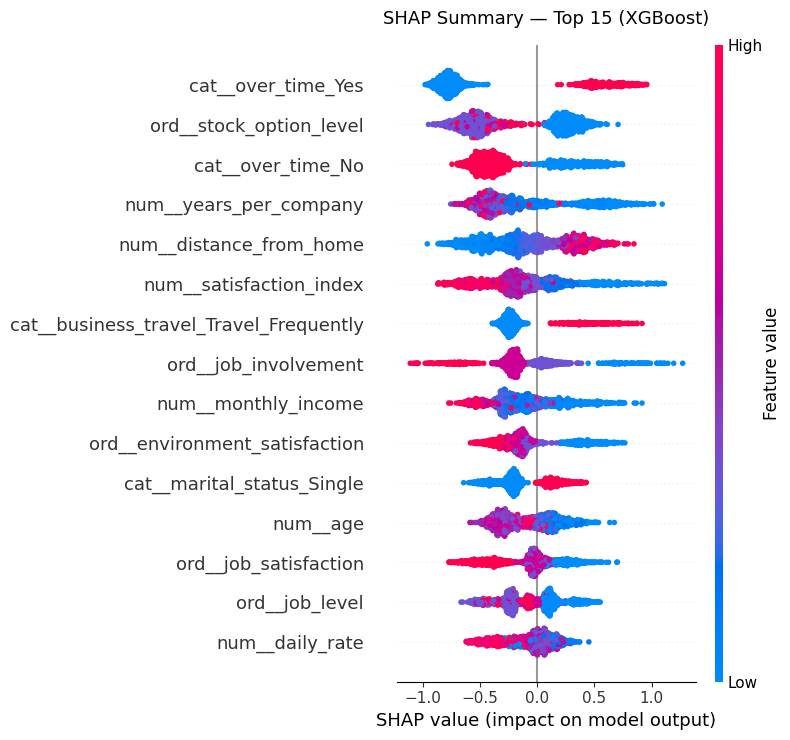

In [123]:
# Summary plot — mostra direção do impacto
import matplotlib.pyplot as plt

plt.figure(figsize=(11, 7))
shap.summary_plot(shap_values, X, feature_names=feature_names,
                  show=False, max_display=15)
plt.title(f'SHAP Summary — Top 15 ({best_name})', fontsize=13, pad=15)
plt.tight_layout()
plt.show()

## 9. Leitura de Negócio dos Principais Fatores

Tradução em linguagem de RH dos fatores mais preditivos — o modelo não toma decisões
por si só; essa leitura é o que transforma um score técnico em ação de retenção.

In [124]:
translation = {
    'over_time_Yes': 'Hora Extra — quem faz hora extra tem risco drasticamente maior',
    'stock_option_level': 'Stock Options — nível 0 = ausência de incentivo de longo prazo',
    'marital_status_Single': 'Estado Civil: Solteiro — grupo com maior rotatividade natural',
    'job_satisfaction': 'Satisfação no Trabalho — driver direto de retenção',
    'environment_satisfaction': 'Satisfação com Ambiente — cultura e relacionamentos no time',
    'monthly_income': 'Salário Mensal — peso maior nos extremos (salários baixos)',
    'job_role_Sales Representative': 'Cargo: Representante de Vendas — função com maior attrition',
    'business_travel_Travel_Frequently': 'Viagens Frequentes — correlação com fadiga e turnover',
    'years_at_company': 'Anos na Empresa — 1-3 anos costuma ser pico de risco',
    'age': 'Idade — jovens (< 35) têm risco 2.2x maior',
    'work_life_balance': 'Equilíbrio Vida-Trabalho — baixo = alto risco',
    'job_involvement': 'Envolvimento no Trabalho — senso de propósito',
    'distance_from_home': 'Distância de Casa — relação linear com attrition',
    'years_since_last_promotion': 'Anos sem Promoção — relação NÃO linear (ver §7)',
    'num_companies_worked': 'Empresas Anteriores — histórico de job-hopping',
}

print('Top 10 fatores — leitura de negócio:\n')
for _, row in importance.head(10).iterrows():
    key = row['feature'].split('__')[-1]
    clean = re.sub(r'^(cat|num|ord)__', '', row['feature'])
    desc = translation.get(key, '(ver documentação técnica)')
    print(f'  • {clean:40s} ({row["importance"]:.3f})')
    print(f'    → {desc}\n')

Top 10 fatores — leitura de negócio:

  • over_time_Yes                            (0.720)
    → Hora Extra — quem faz hora extra tem risco drasticamente maior

  • stock_option_level                       (0.421)
    → Stock Options — nível 0 = ausência de incentivo de longo prazo

  • over_time_No                             (0.405)
    → (ver documentação técnica)

  • years_per_company                        (0.380)
    → (ver documentação técnica)

  • distance_from_home                       (0.319)
    → Distância de Casa — relação linear com attrition

  • satisfaction_index                       (0.304)
    → (ver documentação técnica)

  • business_travel_Travel_Frequently        (0.280)
    → Viagens Frequentes — correlação com fadiga e turnover

  • job_involvement                          (0.269)
    → Envolvimento no Trabalho — senso de propósito

  • monthly_income                           (0.253)
    → Salário Mensal — peso maior nos extremos (salários baixos)

  • env